# Synthetic test case

This synthetic benchmark has 5 scalar observations at one time point for every patient. The data-generating model is

$$
\eta_i \sim \mathcal N(0, \Gamma), \qquad
\phi_i = \exp(\mu + \eta_i), \qquad
y_i = \phi_i + \varepsilon_i, \qquad
\varepsilon_i \sim \mathcal N(0, \initial_variance^2).
$$

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from plotnine import *

from vpop_calibration.api import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
# Data-generating parameters
NB_PATIENTS = 100
TRUE_LOG_MEAN = np.array([-0.2, -0.1, 0, 0.1, 0.2])
TRUE_COV_MATRIX = np.array(
    [
        [1, 0.5, -0.5, 0.2, -0.2],
        [0.5, 1, 0, 0, 0.4],
        [-0.5, 0, 1, 0, 0],
        [0.2, 0, 0, 1, -0.7],
        [-0.2, 0.4, 0, -0.7, 1],
    ]
)
TRUE_NOISE_SD = 0.1
SIMULATION_SEED = 0
DIMENSION = 5

simulation_rng = np.random.default_rng(SIMULATION_SEED)
log_latent_values = simulation_rng.multivariate_normal(
    mean=TRUE_LOG_MEAN, cov=TRUE_COV_MATRIX, size=(NB_PATIENTS,)
)
latent_values = np.exp(log_latent_values)
measurement_errors = simulation_rng.normal(
    loc=0.0, scale=TRUE_NOISE_SD, size=(NB_PATIENTS, DIMENSION)
)
observed_values = latent_values + measurement_errors

# Keep latent values and errors for benchmark evaluation only. They are not passed to SAEM.
rows = [
    {
        "id": f"patient_{i:04d}",
        "time": 0.0,
        "protocol_arm": "identity",
        "output_name": f"y_{j+1}",
        "value": observed_values[i, j],
        "latent_value": latent_values[i, j],
        "measurement_error": measurement_errors[i, j],
    }
    for i in range(NB_PATIENTS)
    for j in range(DIMENSION)
]
input_df = pd.DataFrame(rows)
obs_df = input_df[["id", "time", "protocol_arm", "output_name", "value"]]

display(obs_df)

,id,time,protocol_arm,output_name,value
0,patient_0000,0.0,identity,y_1,0.896984
1,patient_0000,0.0,identity,y_2,0.562476
2,patient_0000,0.0,identity,y_3,0.579136
3,patient_0000,0.0,identity,y_4,0.758787
4,patient_0000,0.0,identity,y_5,1.498399
...,...,...,...,...,...
495,patient_0099,0.0,identity,y_1,1.369033
496,patient_0099,0.0,identity,y_2,0.467866
497,patient_0099,0.0,identity,y_3,0.404288
498,patient_0099,0.0,identity,y_4,7.002938


In [22]:
def one_point_model(x_1, x_2, x_3, x_4, x_5, t):
    levels = torch.cat((x_1, x_2, x_3, x_4, x_5), dim=-1)
    return levels + torch.zeros_like(t)


struct_model = StructuralAnalytical(
    one_point_model, [f"y_{j+1}" for j in range(DIMENSION)]
)

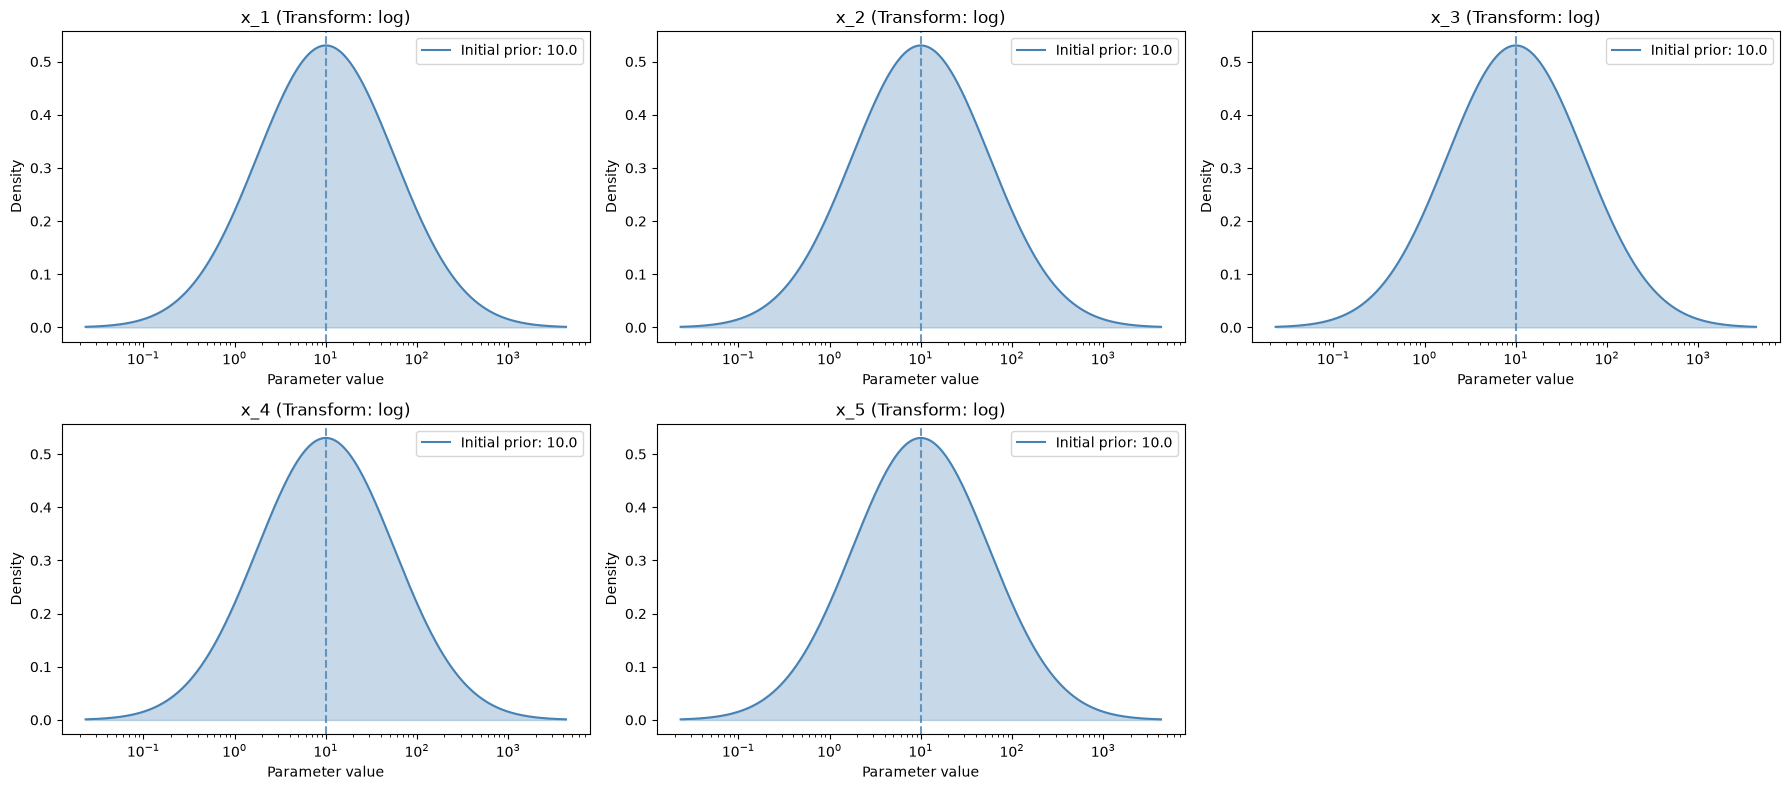

In [23]:
# Initial values are intentionally different from the data-generating values.
model_params = {
    "pdu": {
        f"x_{j+1}": {
            "prior": 10,
            "prior_omega": 3,  # Initial log-scale variance (SD = 0.5)
        }
        for j in range(DIMENSION)
    },
    "error_model": {
        f"y_{j+1}": {
            "error_type": "additive",
            "initial_variance": 4.0,  # Initial residual variance (SD = 2.0)
        }
        for j in range(DIMENSION)
    },
}

config = Config(
    seed=2026,
    nlme=NlmeConfigDict(
        nb_chains=1,
        live_plot=True,
        progress_bar=True,
    ),
    saem=SaemConfigDict(
        nb_iter_burnin=30,
        nb_iter_learning=270,
        nb_iter_smoothing=200,
        nb_mcmc_transitions=5,
        learning_rate_power=0.7,
        live_plot=True,
        progress_bars=True,
        logging=False,
    ),
)

nlme_model = NlmeModel(
    structural_model=struct_model,
    df=obs_df,
    input_params=model_params,
    config=config,
)
nlme_model.initial_estimates.plot_distribution(log_scale=True)

  0%|          | 0/500 [00:00<?, ?it/s]

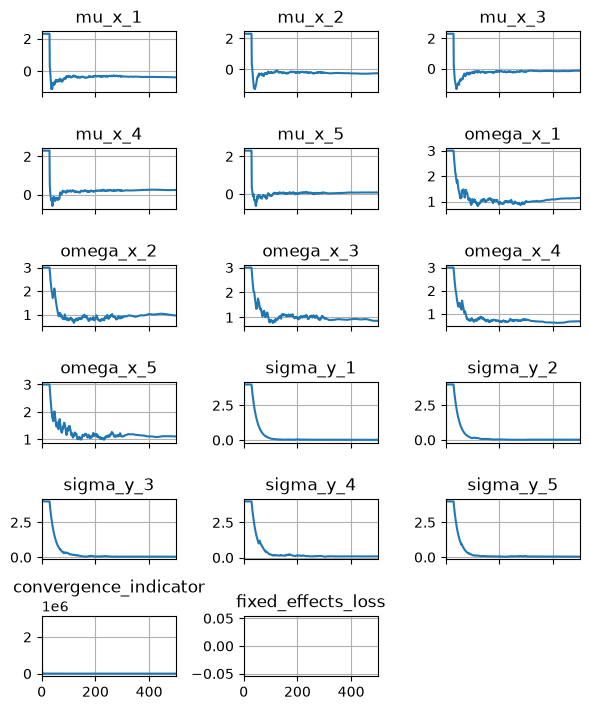

tensor([-0.3838, -0.2445, -0.1360,  0.2447,  0.0887])

In [24]:
nlme_model.optimizer.run()
nlme_model.statistical_model.population_betas

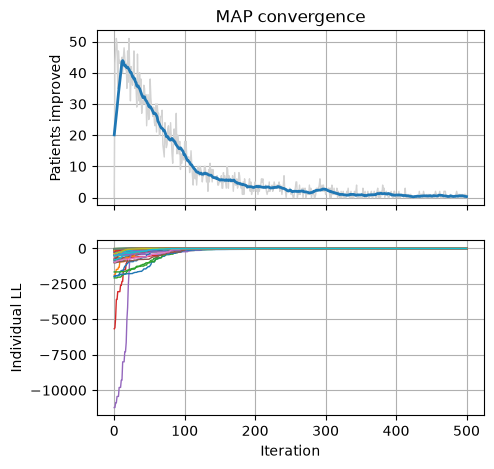

  0%|          | 0/500 [00:00<?, ?it/s]

In [26]:
nlme_model.diagnostics.sample_conditional_distribution(nb_samples=500)

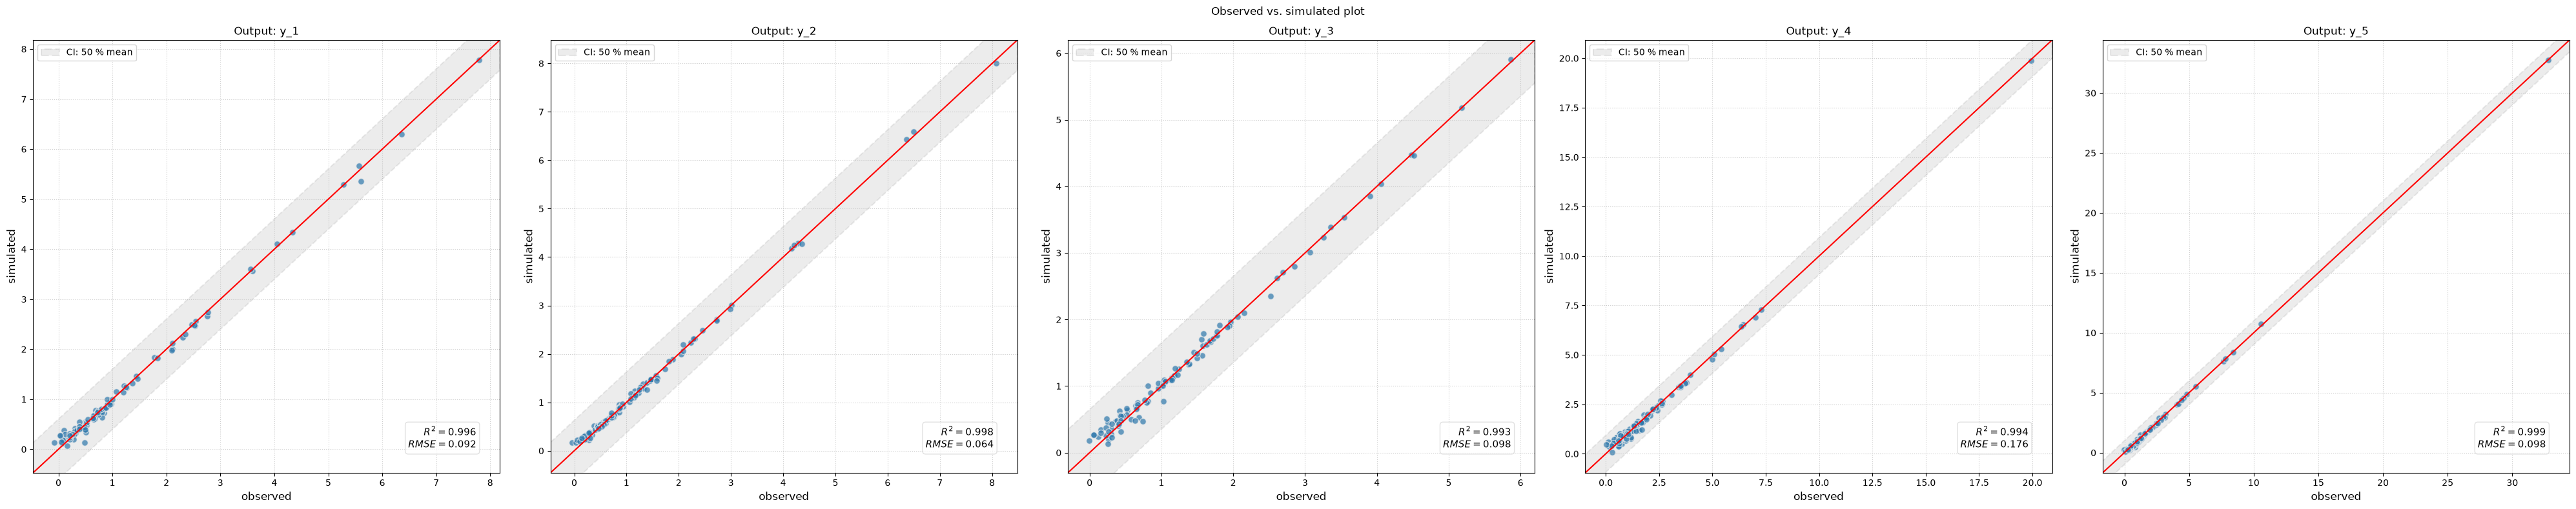

In [27]:
nlme_model.plot.map_estimates_gof()

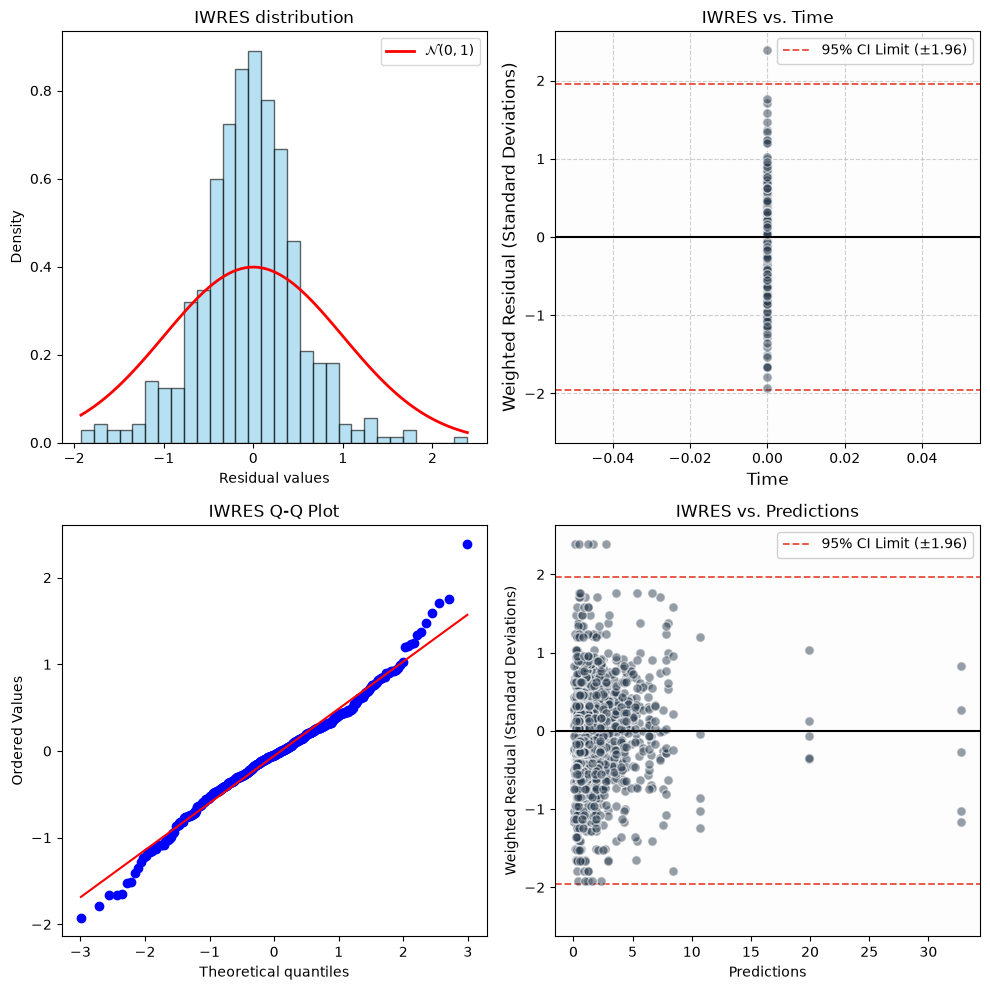

In [28]:
nlme_model.plot.weighted_residuals("iwres")

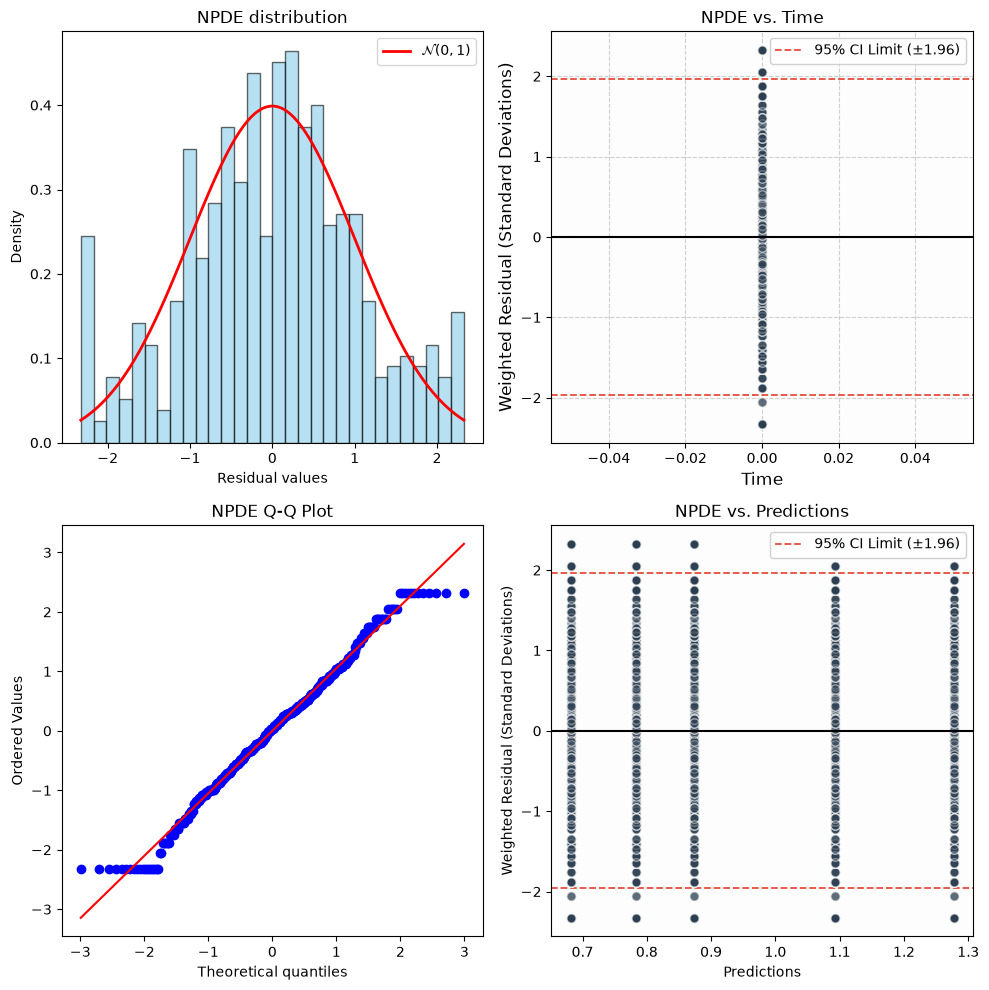

In [29]:
nlme_model.plot.weighted_residuals("npde")

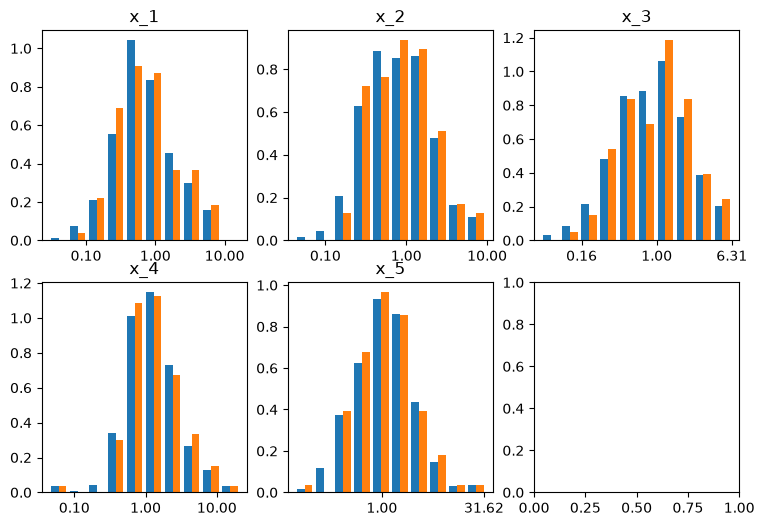

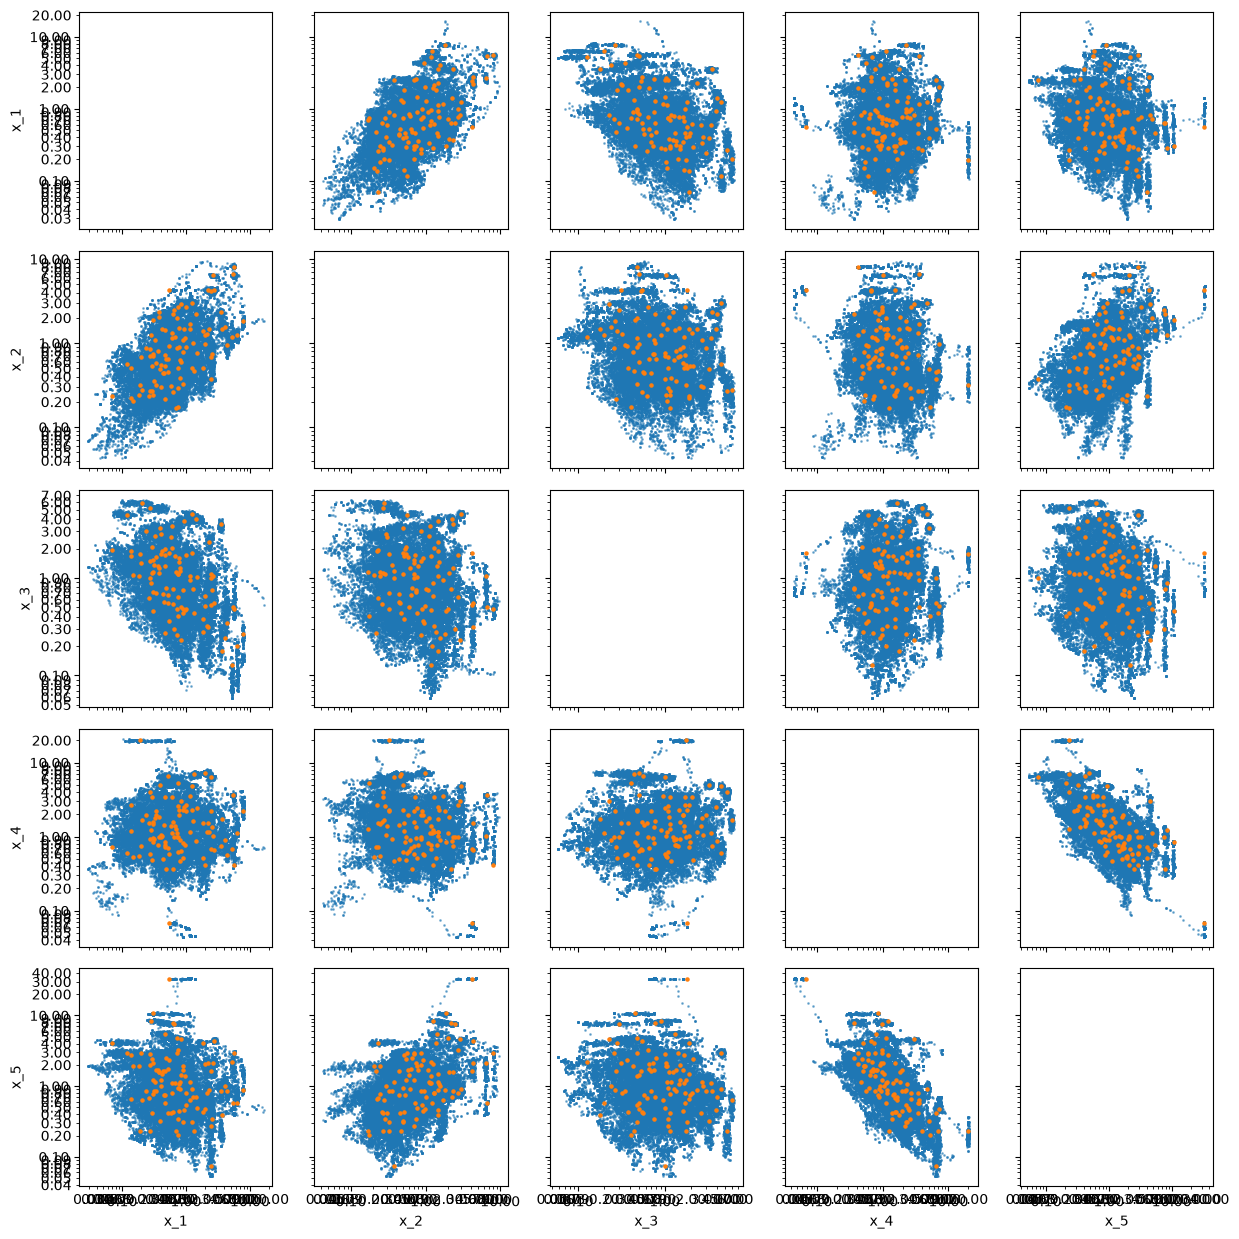

In [30]:
nlme_model.plot.conditional_codistributions()

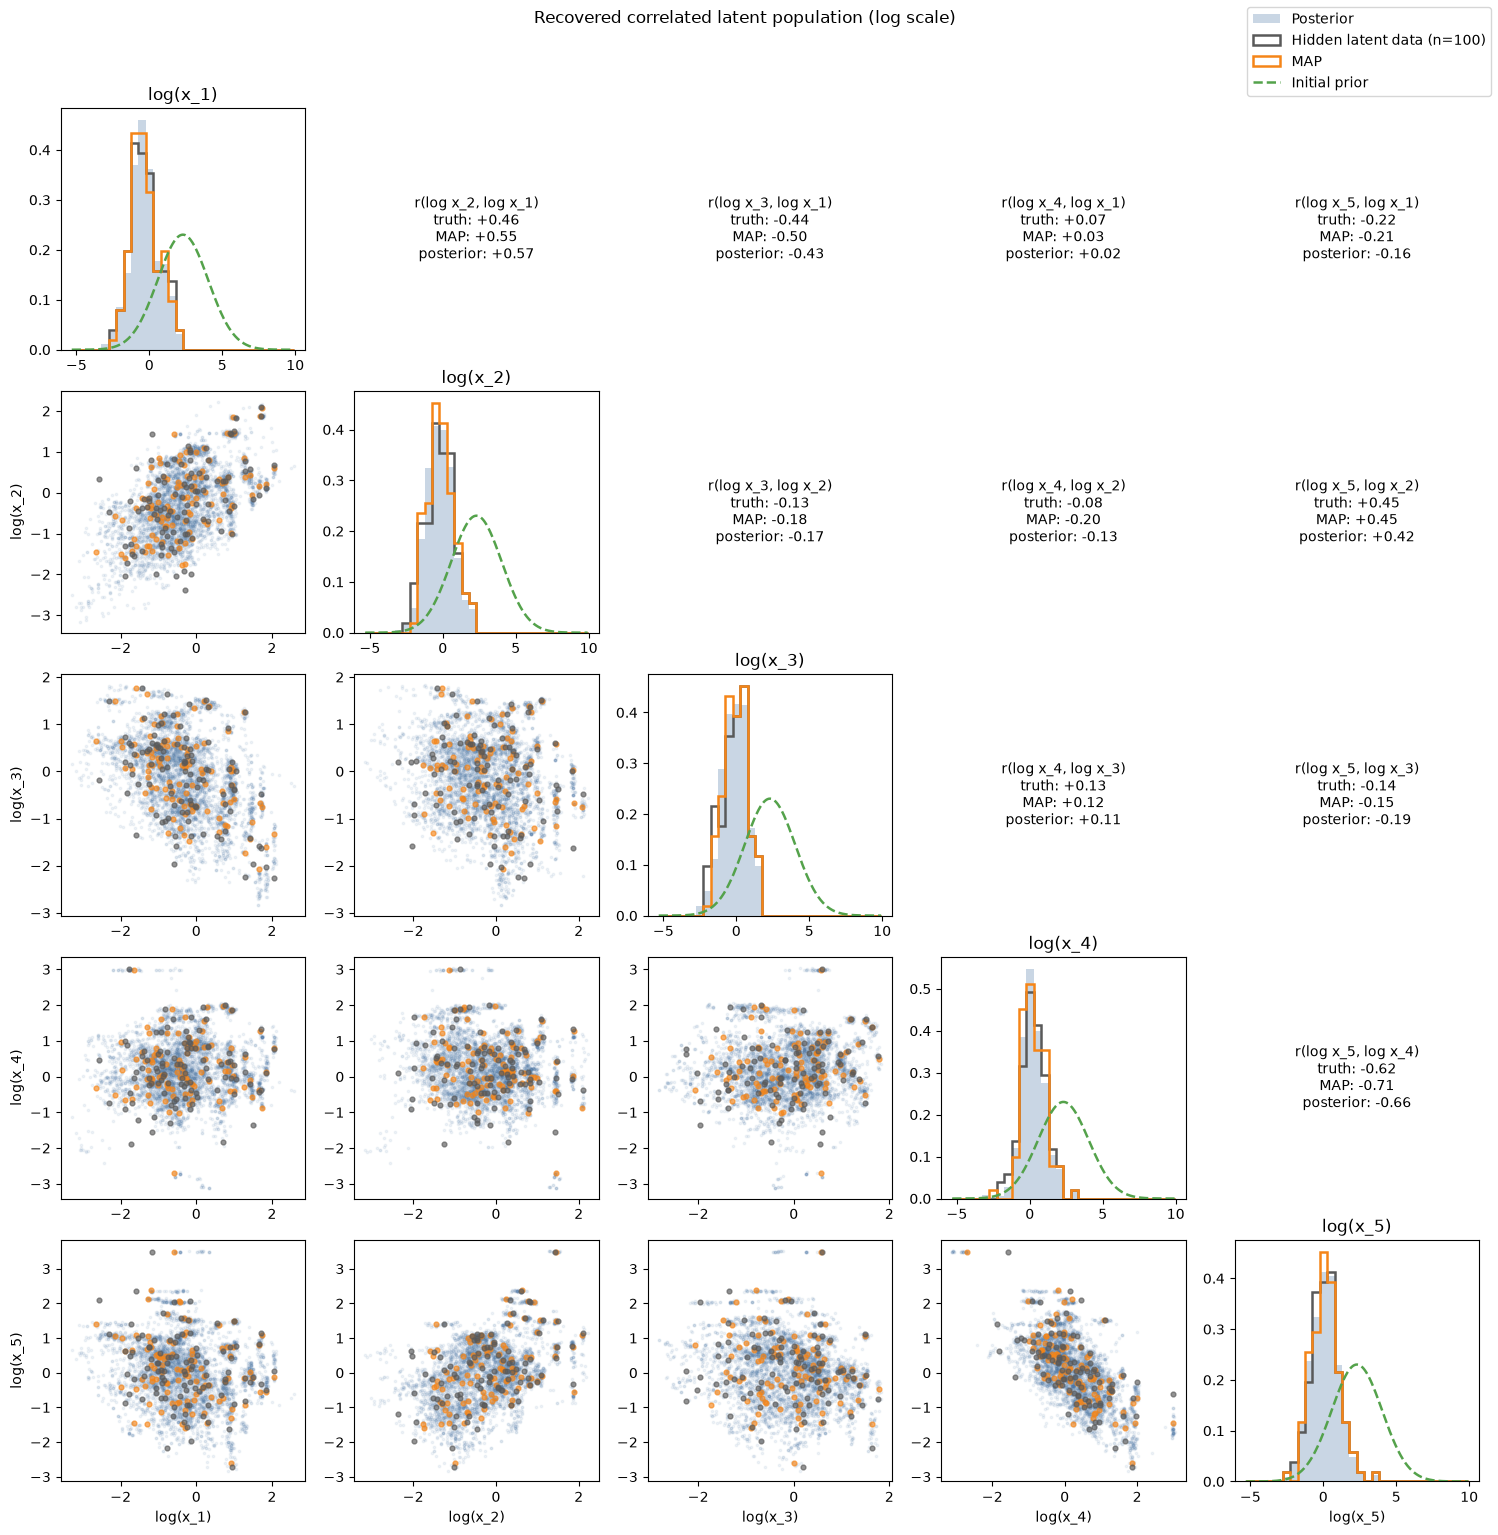

In [31]:
# The correlated model has one PDU per output.  Plot the marginal
# distributions on the diagonal and their joint distributions below it.
sampler = nlme_model.diagnostics.sampler
if not hasattr(sampler, "samples"):
    nlme_model.diagnostics.sample_conditional_distribution(nb_samples=200)

pdu_names = nlme_model.statistical_model.pdu_names
posterior_df = sampler.total_samples_parameters_df
map_df = sampler.map_parameters_df

true_log_df = pd.DataFrame(log_latent_values, columns=pdu_names)
posterior_for_plot = posterior_df.sample(
    n=min(5_000, len(posterior_df)), random_state=SIMULATION_SEED
)[pdu_names]

# Work directly with log(PDUs): their marginals are Gaussian.
posterior_log_df = np.log(posterior_for_plot)
map_log_df = np.log(map_df[pdu_names])
realized_log_corr = np.corrcoef(true_log_df.to_numpy(), rowvar=False)
posterior_log_corr = np.corrcoef(posterior_log_df.to_numpy(), rowvar=False)
map_log_corr = np.corrcoef(map_log_df.to_numpy(), rowvar=False)

pdu_priors = nlme_model.statistical_model.input_params.pdu
prior_log_mean = np.array([pdu_priors[name].transformed_prior for name in pdu_names])
prior_log_sd = np.sqrt([pdu_priors[name].prior_omega for name in pdu_names])

all_log_values = np.concatenate(
    [
        true_log_df.to_numpy().ravel(),
        posterior_log_df.to_numpy().ravel(),
        map_log_df.to_numpy().ravel(),
    ]
)
x_lower = min(all_log_values.min(), (prior_log_mean - 4.0 * prior_log_sd).min())
x_upper = max(all_log_values.max(), (prior_log_mean + 4.0 * prior_log_sd).max())
padding = 0.05 * (x_upper - x_lower)
x_lower, x_upper = x_lower - padding, x_upper + padding
bin_edges = np.linspace(x_lower, x_upper, 31)
x = np.linspace(x_lower, x_upper, 500)

n_pdu = len(pdu_names)
fig, axes = plt.subplots(
    n_pdu, n_pdu, figsize=(3.0 * n_pdu, 3.0 * n_pdu), squeeze=False
)

for row, y_name in enumerate(pdu_names):
    for col, x_name in enumerate(pdu_names):
        ax = axes[row, col]
        if row == col:
            ax.hist(
                posterior_log_df[x_name],
                bins=bin_edges,
                density=True,
                alpha=0.30,
                color="#4C78A8",
                label="Posterior",
            )
            ax.hist(
                true_log_df[x_name],
                bins=bin_edges,
                density=True,
                histtype="step",
                linewidth=1.8,
                color="#595959",
                label="Hidden latent data (n=100)",
            )
            ax.hist(
                map_log_df[x_name],
                bins=bin_edges,
                density=True,
                histtype="step",
                linewidth=1.8,
                color="#F58518",
                label="MAP",
            )
            true_log_mean = TRUE_LOG_MEAN[row]
            true_log_sd = np.sqrt(TRUE_COV_MATRIX[row, row])
            true_pdf = np.exp(-0.5 * ((x - true_log_mean) / true_log_sd) ** 2) / (
                true_log_sd * np.sqrt(2.0 * np.pi)
            )
            # ax.plot(x, true_pdf, color="black", linewidth=1.8, label="True population")
            prior_pdf = np.exp(
                -0.5 * ((x - prior_log_mean[row]) / prior_log_sd[row]) ** 2
            ) / (prior_log_sd[row] * np.sqrt(2.0 * np.pi))
            ax.plot(
                x,
                prior_pdf,
                color="#54A24B",
                linewidth=1.8,
                linestyle="--",
                label="Initial prior",
            )
            ax.set_title(f"log({x_name})")
        elif row > col:
            ax.scatter(
                posterior_log_df[x_name],
                posterior_log_df[y_name],
                s=3,
                alpha=0.08,
                color="#4C78A8",
                label="Posterior",
            )
            ax.scatter(
                map_log_df[x_name],
                map_log_df[y_name],
                s=12,
                alpha=0.65,
                color="#F58518",
                label="MAP",
            )
            ax.scatter(
                true_log_df[x_name],
                true_log_df[y_name],
                s=12,
                alpha=0.65,
                color="#595959",
                label="Simulated latent data",
            )
        else:
            ax.axis("off")
            ax.text(
                0.5,
                0.5,
                f"r(log {x_name}, log {y_name})\n"
                f"truth: {realized_log_corr[row, col]:+.2f}\n"
                f"MAP: {map_log_corr[row, col]:+.2f}\n"
                f"posterior: {posterior_log_corr[row, col]:+.2f}",
                ha="center",
                va="center",
                fontsize=10,
            )

        if row == n_pdu - 1:
            ax.set_xlabel(f"log({x_name})")
        if col == 0 and row != col:
            ax.set_ylabel(f"log({y_name})")

fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper right")
fig.suptitle("Recovered correlated latent population (log scale)", y=1.02)
fig.tight_layout()

In [32]:
nlme_model.diagnostics.compute_shrinkage()
print(f"shrinkage = {nlme_model.diagnostics.shrinkage}")

shrinkage = tensor([0.0818, 0.1005, 0.1049, 0.0064, 0.0589])


In [33]:
nlme_model.diagnostics.compute_log_likelihood_importance_sampling(
    nb_proposal_samples=1000
)
print(
    f"Estimated log-likelihood: {nlme_model.diagnostics.importance_sampler.log_lik:.3f}"
)

Estimated log-likelihood: -757.330
